Dataset pada github : https://raw.githubusercontent.com/selva86/datasets/master/a10.csv 

# Import Library

In [ ]:
!pip install numpy==1.26.4 pmdarima

import numpy
import pmdarima
print("Numpy version:", numpy.__version__)
print("pmdarima version:", pmdarima.__version__)


Numpy version: 1.26.4
pmdarima version: 2.0.4


In [ ]:
# Import library untuk manipulasi dan analisis data dalam bentuk tabel
# Untuk membaca dan mengolah data dalam bentuk DataFrame
import pandas as pd

# Import fungsi ADF (Augmented Dickey-Fuller) Test dari statsmodels untuk uji stasioneritas data time series
# Untuk menguji apakah data time series stasioner
from statsmodels.tsa.stattools import adfuller

# Import matplotlib untuk visualisasi data seperti grafik tren dan forecast
# Untuk membuat grafik
import matplotlib.pyplot as plt

# Import Exponential Smoothing (ETS) model dari statsmodels untuk data dengan tren dan musiman
# Untuk model ETS (trend dan seasonality)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Import MAPE dari sklearn untuk mengevaluasi akurasi model forecasting
# Untuk menghitung error model (semakin kecil semakin baik)
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

# Import joblib untuk menyimpan dan memuat model yang sudah dilatih
import joblib  # Untuk save/load model ke file .pkl (agar tidak perlu dilatih ulang)

from pmdarima.arima import auto_arima

## Load Dataset

In [ ]:
# Gunakan dataset dibawah ini
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'])

In [ ]:
df

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869
...,...,...
199,2008-02-01,21.654285
200,2008-03-01,18.264945
201,2008-04-01,23.107677
202,2008-05-01,22.912510


In [ ]:
df.describe()

,date,value
count,204,204.000000
mean,1999-12-16 10:49:24.705882368,10.694430
min,1991-07-01 00:00:00,2.814520
25%,1995-09-23 12:00:00,5.844095
50%,1999-12-16 12:00:00,9.319345
75%,2004-03-08 18:00:00,14.289964
max,2008-06-01 00:00:00,29.665356
std,NaN,5.956998


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    204 non-null    datetime64[ns]
 1   value   204 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.3 KB


In [ ]:
# Drop missing rows
df_clean = df.dropna()

In [ ]:
df_clean.isnull().sum()

,0
date,0
value,0


In [ ]:
# # Mengambil kolom date tanggal saja dan lakukan agregasi
daily_revenue = df_clean.groupby(df_clean['date'].dt.date)['value'].sum().reset_index()

# Rename kolom agar lebih deskriptif
daily_revenue.columns = ['Date', 'Total_Revenue']

# Konversi kembali kolom 'Date' ke datetime agar bisa dipakai untuk plotting atau time series model
daily_revenue['Date'] = pd.to_datetime(daily_revenue['Date'])

# Tampilkan hasilnya
daily_revenue.head(1)

,Date,Total_Revenue
0,1991-07-01,3.526591


In [ ]:
# Atur kolom 'Date' sebagai index dari DataFrame
# Ambil hanya kolom 'Total_Revenue' sehingga hasilnya menjadi time series (seri waktu) murni

ts = daily_revenue.set_index('Date')['Total_Revenue']
ts.head()

,Total_Revenue
Date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


## Proses Time Series Analysis

### checking plot trend

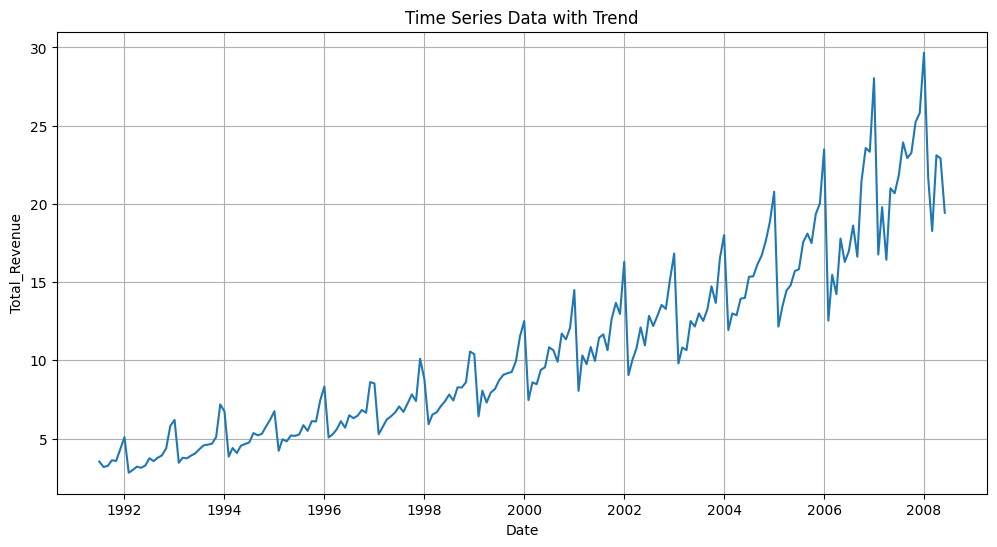

In [ ]:
# Ploting Tren
plt.figure(figsize=(12, 6))
plt.plot(ts)
plt.title('Time Series Data with Trend')
plt.xlabel('Date')
plt.ylabel('Total_Revenue')
plt.grid(True)
plt.show()

Tren Positif Jangka Panjang: terlihat bahwa nilai Total_revenue cenderung meningkat seiring berjalannya waktu dari tahun 1991 hingga 2008. Yang menunjukkan adanya tren naik (uptrend) pada data.


### Plot seasonality

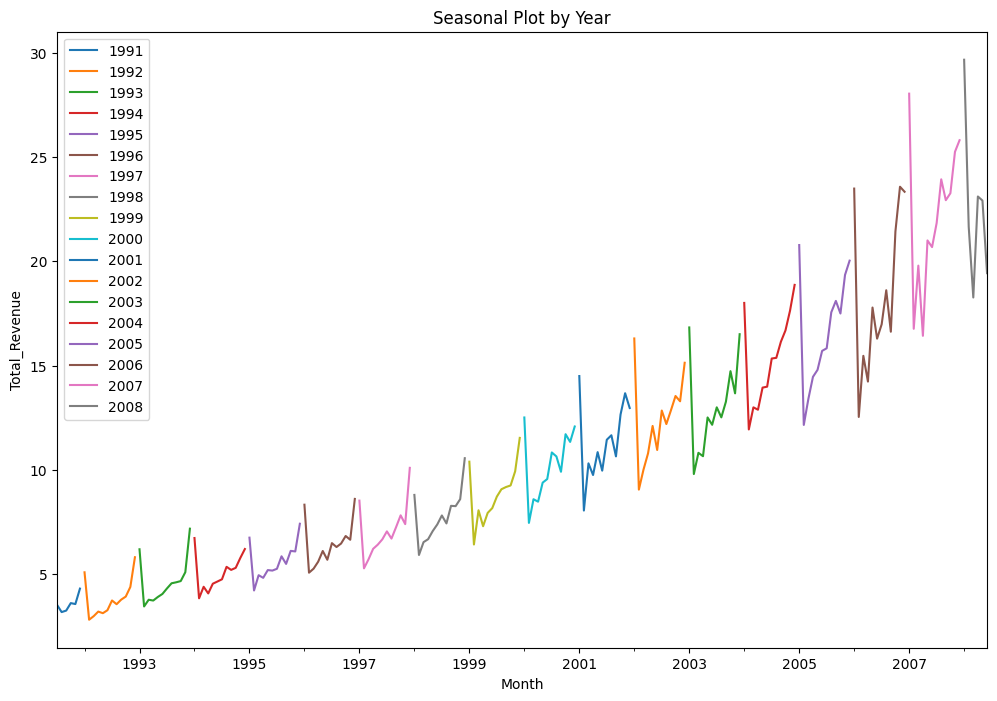

In [ ]:
# Plotting seasonality by year
plt.figure(figsize=(12, 8))
ts.groupby(ts.index.year).plot(legend=True)
plt.title('Seasonal Plot by Year')
plt.xlabel('Month')
plt.ylabel('Total_Revenue')
plt.show()

Berdasarkan plot musiman per tahun (Seasonal Plot by Year) insight yang didapatkan:

- Pola Musiman Tahunan yang Konsisten: Dapat dilihat bahwa setiap tahun, data menunjukkan pola yang berulang secara konsisten. Ada periode di mana nilai Total_Revenue cenderung naik, mencapai puncak, kemudian turun, dan kembali naik di periode yang sama setiap tahunnya. dengan puncak di akhir tahun dan lembah di awal tahun, serta amplitudo musiman yang meningkat dari waktu ke waktu.





### Checking periode seasonality

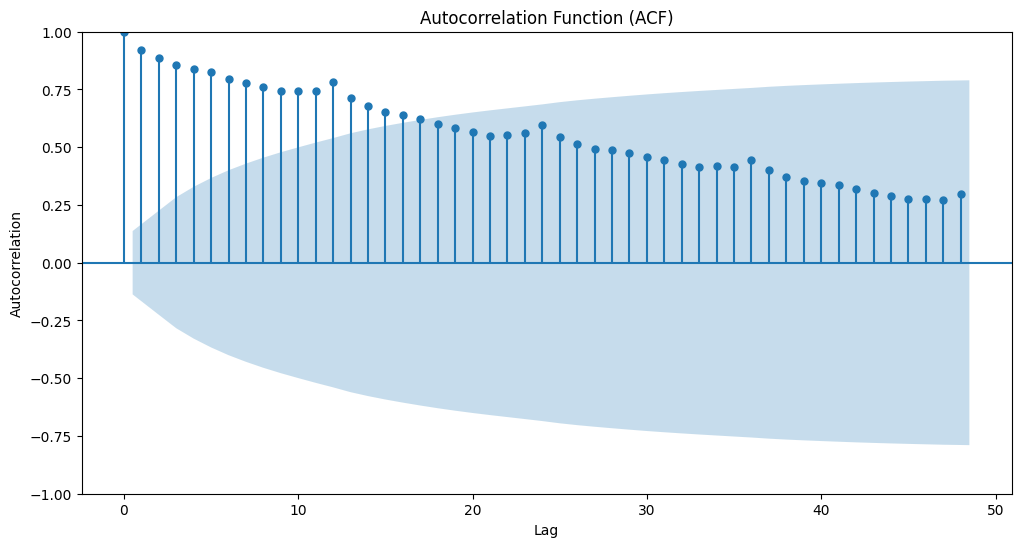

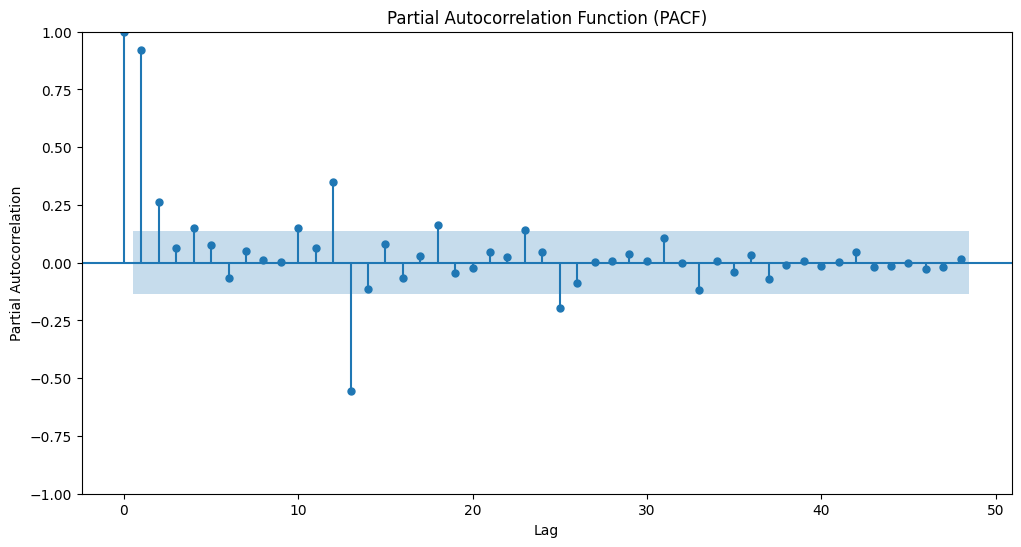

In [ ]:
# checking periode seasonality
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Untuk memvisualisasi AFC dan PACF

# Plot ACF
# Untuk melihat pola korelasi yang berulang secara musiman
plt.figure(figsize=(12, 6))
plot_acf(ts, lags=48, ax=plt.gca()) # Lags up to 48 (4 years)
plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

# Plot PACF
# Korelasi langsung antar titik waktu
plt.figure(figsize=(12, 6))
plot_pacf(ts, lags=48, ax=plt.gca()) # Lags up to 48 (4 years)
plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

Plot ACF:<br>

- Autokorelasi yang Menurun Perlahan: Garis autokorelasi pada plot ACF menurun secara perlahan dan tetap signifikan (berada di luar area biru) untuk banyak lag pertama.
- Puncak Signifikan pada Kelipatan 12: Terlihat puncak-puncak yang signifikan (garis melewati area biru) pada lag 12, 24, 36, dan seterusnya. Yang mengkonfirmasi adanya pola musiman tahunan dengan periode 12 bulan. Puncak-puncak ini menunjukkan bahwa nilai data saat ini sangat berkorelasi dengan nilai data 12 bulan, 24 bulan, 36 bulan sebelumnya, dan seterusnya.

Dari Plot PACF:

- Lag Pertama Signifikan: Terdapat lonjakan signifikan pada lag pertama, yang umum terjadi pada sebagian besar data time series.
- Puncak Signifikan pada Lag 12: Ada lonjakan signifikan pada lag 12, yang merupakan indikasi adanya komponen musiman langsung pada periode 12 bulan. Setelah lag 12, nilai PACF cenderung menurun tajam atau menjadi tidak signifikan.

Kesimpulan dari ACF dan PACF:

Keberadaan autokorelasi yang menurun perlahan pada plot ACF yang dapat mengkonfirmasi bahwa data tidak stasioner karena adanya tren.
Puncak signifikan pada lag 12, 24, 36, dan seterusnya pada plot ACF, serta lonjakan signifikan pada lag 12 pada plot PACF, mengkonfirmasi adanya musiman tahunan dengan periode 12 bulan.




### Checking additive or multiplicative

<Figure size 1200x1000 with 0 Axes>

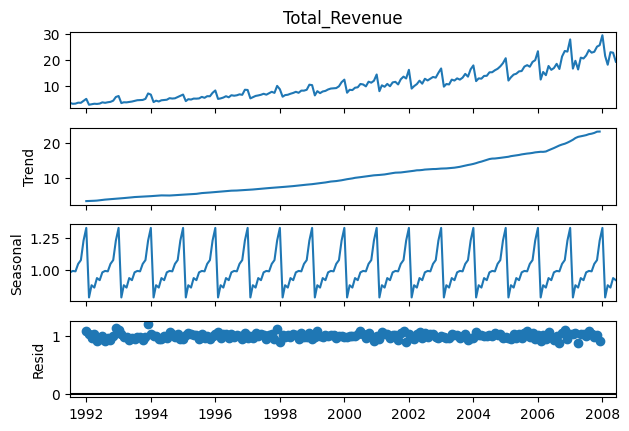

In [ ]:
# checking multiplicative
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform multiplicative decomposition
multiplicative_decomposition = seasonal_decompose(ts, model='multiplicative', period=12) # Assuming monthly data, period=12

plt.figure(figsize=(12, 10))
plt.suptitle('Multiplicative Decomposition', fontsize=16)
multiplicative_decomposition.plot()
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

Alasan saya menggunakan multiplicative karena data yang di analisis terlihat bahwa rentang naik turun pada akhir tahun-tahun terakhir (saat nilai Total_Revenue tinggi) cenderung lebih besar dibandingkan pada awal tahun-tahun pertama (saat nilai Total_Revenue rendah). Dan juga amplitudo pola musiman pada plot data cenderung meningkat seiring dengan peningkatan nilai tren.

Insight:<br>
Berdasarkan hasil Perform multiplicative decomposition

- Observed: Plot  menunjukkan tren naik jangka panjang dan pola musiman yang kuat.
- Trend: Plot tren menunjukkan pergerakan jangka panjang dari data,  Pada plot tren, terlihat jelas adanya tren naik yang stabil dari waktu ke waktu, mengkonfirmasi pengamatan sebelumnya bahwa data memiliki tren positif.
- Seasonal: Plot musiman menunjukkan pola yang berulang dalam periode tertentu (dalam kasus ini, 12 bulan). Terlihat pola musiman yang konsisten setiap tahunnya, dengan puncak dan lembah yang terjadi pada bulan-bulan yang sama.
- Residual: Plot residual menunjukkan sisa data setelah tren dan musiman dihilangkan. Residual idealnya harus terlihat seperti white noise (acak dan tidak memiliki pola). Pada plot ini, residual terlihat cukup acak, meskipun mungkin ada beberapa titik yang menunjukkan variabilitas yang lebih tinggi. Residual ini merepresentasikan fluktuasi yang tidak dijelaskan oleh tren atau musiman.

Mengapa Multiplikatif Lebih Cocok?

Seperti yang kita diskusikan sebelumnya, pemilihan model multiplikatif didukung oleh fakta bahwa amplitudo pola musiman pada plot data asli (dan terlihat juga pada komponen musiman hasil dekomposisi multiplikatif) cenderung meningkat seiring dengan peningkatan nilai tren. Jika Anda membandingkan dengan hasil dekomposisi aditif (jika Anda mencobanya), komponen musiman pada dekomposisi aditif akan memiliki amplitudo yang konstan, yang kurang sesuai dengan pola yang terlihat pada data asli.

Dengan menggunakan dekomposisi multiplikatif, kita mengasumsikan bahwa besarnya efek musiman adalah proporsional terhadap tingkat data.

### Checking stationary

In [ ]:
# Melakuka uji ADF (Augmented Dickey-Fuller) untuk mengecek apakah data time series stasioner atau tidak
# Data dikatakan stasioner jika p-value < 0.05 (artinya tidak ada akar unit/root)

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts)  # Jalankan ADF Test
print(f'ADF Statistic: {adf_result[0]}')  # Nilai statistik ADF (semakin kecil = lebih stasioner)
print(f'p-value: {adf_result[1]}')        # p-value hasil uji, jika < 0.05 berarti data stasioner

# Interpretasi hasil
if adf_result[1] < 0.05:
    print("Kesimpulan: Data time series terlihat stasioner (berdasarkan p-value < 0.05)")
else:
    print("Kesimpulan: Data time series terlihat tidak stasioner (berdasarkan p-value >= 0.05)")

ADF Statistic: 3.14518568930673
p-value: 1.0
Kesimpulan: Data time series terlihat tidak stasioner (berdasarkan p-value >= 0.05)


Insight:
Berdasarkan hasil uji Augmented Dickey-Fuller (ADF):<br>

- Nilai p-value yang didapatkan adalah 1.0.
- Karena p-value (1.0) lebih besar dari tingkat signifikansi umum (misalnya 0.05), kita gagal menolak hipotesis nol dari uji ADF.

Kesimpulan: Data time series tidak stasioner.<br>

- Hasil yang di dapatkan  konsisten dengan observasi sebelumnya dari plot tren dan plot musiman yang menunjukkan adanya tren naik jangka panjang dan pola musiman yang jelas.

### Petunjuk Assignment II :
1. Setelah anda melakukan timeseries analysis, maka langkah selanjutnya ialah timeseries forecasting.
2. Lakukan pre-processing data / feature engineering untuk mengubah data non-stationary menjadi data stationary dengan transformation method. (20 Poin)
3. Setelah datanya menjadi stationary dari hasil transformation method yang anda pilih, kita gunakan data tersebut untuk proses modelling timeseries, menggunakan Auto ARIMA untuk melakukan :
- training model + setting parameter (5 poin)
- Full forecast all dataset (train + test) (5 poin)
- evaluate in full forecasting (5 poin)
- evaluate in data test (5 poin)
- evaluate in data train (5 poin)
- Future Prediction (5 poin)

## Feature Engineering

In [ ]:
# karena data tidak stasioner (p-value > 0.05), maka dilakukan transformasi data
# Menerapkan log transform untuk menstabilkan varians
ts_log = numpy.log(ts)

# Menerapkan differencing (pengurangan nilai dengan nilai sebelumnya)
# Dengan tujuan untuk menghilangkan tren agar data menjadi lebih stasioner
# diff() akan menghasilkan NaN baris pertama, maka digunakan .dropna()
ts_log_diff = ts_log.diff().dropna()

In [ ]:
# Melakukan uji ADF lagi setelah transformasi log dan differencing
# Dengan tujuan untuk memastikan data sudah menjadi stasioner

adf_result_diff = adfuller(ts_log_diff)
print(f'ADF Statistic: {adf_result_diff[0]}')
print(f'p-value: {adf_result_diff[1]}')

ADF Statistic: -4.51943242629711
p-value: 0.00018133843740901967


## Proses Modelling Timeseries

In [ ]:
# Pisahkan data menjadi data latih (train) dan data uji (test)
# Menggunakan 80% data awal untuk latih dan 20% data akhir untuk uji

train_size = int(len(ts_log_diff) * 0.8)
train_data, test_data = ts_log_diff[0:train_size], ts_log_diff[train_size:]

print(f'Jumlah data latih: {len(train_data)}')
print(f'Jumlah data uji: {len(test_data)}')

Jumlah data latih: 162
Jumlah data uji: 41


### Training Model

In [ ]:
# training model
arima_model = auto_arima(train_data, start_p=0, d=1, start_q=0,
                         max_p=5, max_d=5, max_q=5, start_P=0,
                         D=1, start_Q=0, max_P=5, max_D=5,
                         max_Q=5, m=12, seasonal=True,
                         error_action='warn', trace=True,
                         suppress_warnings=True, stepwise=True,
                         random_state=20, n_fits=50)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-170.188, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-257.843, Time=0.27 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.19 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(5,1,2)(0,1,2)[12]             : AIC=-419.929, Time=5.67 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,1,2)(0,1,2)[12]             : AIC=inf, Time=7.59 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(5,1,1)(0,1,2)[12] intercept   : AIC=-424.071, Time=11.36 sec

Best model:  ARIMA(5,1,1)(0,1,2)[12]          
Total fit time: 209.999 seconds


### Full Forecast

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


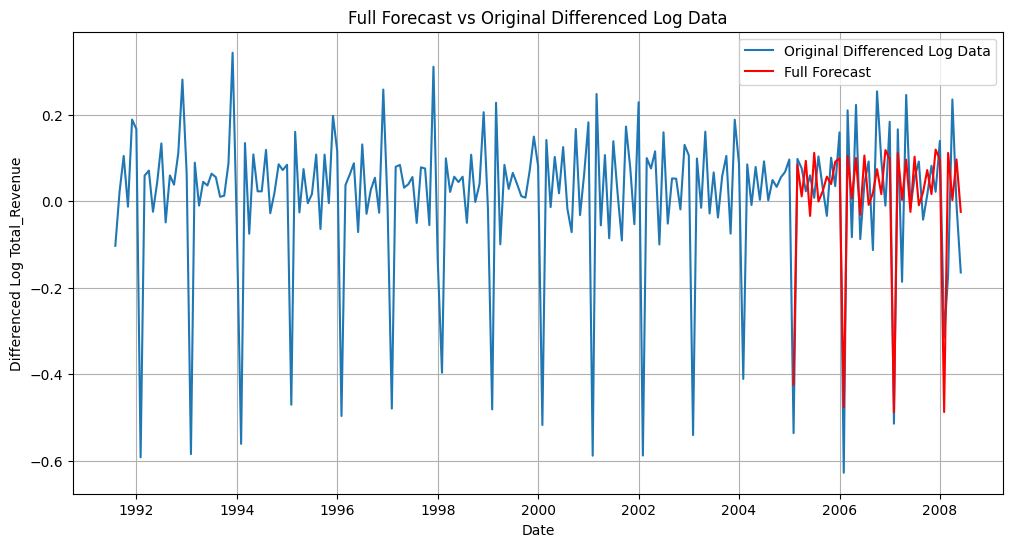

In [ ]:
# Full forecast untuk seluruh datase (train + test)
full_forecast = arima_model.predict(n_periods=len(ts_log_diff))

# Membuat pandas Series untuk full forecast dengan indek yang benar
full_forecast_series = pd.Series(full_forecast, index=ts_log_diff.index)

# Plot data asli yang telah diubah log-transformed data dan full forecast
plt.figure(figsize=(12, 6))
plt.plot(ts_log_diff, label='Original Differenced Log Data')
plt.plot(full_forecast_series, color='red', label='Full Forecast')
plt.title('Full Forecast vs Original Differenced Log Data')
plt.xlabel('Date')
plt.ylabel('Differenced Log Total_Revenue')
plt.legend()
plt.grid(True)
plt.show()

Pada Grafik:

- Kesesuaian yang Baik dengan Pola Historis: red line yang mewakili “Full Forecast” secara umum mengikuti pergerakan dan fluktuasi “Original Differenced Log Data” (blue line) dengan cukup baik. Yang menunjukkan bahwa model Auto ARIMA telah menangkap pola dasar dalam data, termasuk musiman dan tren yang telah dibedakan.
- Capturing Seasonality (Menangkap Musiman): Terlihat bahwa puncak dan lembah dalam full forecast sejalan dengan baik dengan puncak dan lembah dalam data asli. Hal ini menunjukkan bahwa komponen musiman yang diidentifikasi oleh model Auto ARIMA akurat untuk data log diferensiasi.
- Handling Variability (Mengelola Variabilitas): Terlihat model mampu menangkap sebagian variabilitas dalam data diferensiasi, meskipun ada kemungkinan puncak atau lembah sedikit underestimated atau overestimated.

Secara keseluruhan: Full Forecast memberikan representasi visual yang baik tentang bagaimana model Auto ARIMA yang dipilih cocok dengan data historis yang stasioner. Menunjukkan bahwa transformasi (log dan differencing) serta pemilihan model oleh auto_arima efektif dalam menangkap karakteristik utama dari rangkaian waktu.


### Evaluate Full Forecasting

In [ ]:
# Evaluate full forecast using matric
# MAE, MSE, dan MAPE sebagai matric evaluasi

# Ensure both series have the same length and no NaNs by dropping NaNs from the forecast
full_forecast_series_cleaned = full_forecast_series.dropna()
ts_log_diff_cleaned = ts_log_diff[full_forecast_series_cleaned.index] # Align ts_log_diff with the cleaned forecast index

# Menghitung Mean Absolute Error (MAE)
mae_full = mean_absolute_error(ts_log_diff_cleaned, full_forecast_series_cleaned)

# Menghitung Mean Squared Error (MSE)
mse_full = mean_squared_error(ts_log_diff_cleaned, full_forecast_series_cleaned)

# Menghitung Mean Absolute Percentage Error (MAPE)
# Menghindari pembagian nol pada MAPE
# Add a small epsilon to avoid division by zero in case of zero actual values
epsilon = 1e-10
mape_full = mean_absolute_percentage_error(ts_log_diff_cleaned, full_forecast_series_cleaned)


print(f'Full Forecast Evaluation:')
print(f'  MAE: {mae_full:.4f}')
print(f'  MSE: {mse_full:.4f}')
print(f'  MAPE: {mape_full:.4f}')

Full Forecast Evaluation:
  MAE: 0.0969
  MSE: 0.0126
  MAPE: 1.9256


- MAE (Mean Absolute Error): 0.0969
yang berarti, rata-rata, selisih absolut antara Full forecast model dan data log yang sebenarnya adalah sekitar 0.0969. Nilai MAE yang lebih rendah menunjukkan akurasi yang lebih baik.
- MSE (Mean Squared Error): 0.0126
Metrik MSE mengkuadratkan kesalahan sebelum menghitung rata-ratanya, sehingga memberikan bobot lebih besar pada kesalahan yang lebih besar. Nilai MSE yang lebih rendah juga menunjukkan akurasi yang lebih baik. Nilai 0.0126 menunjukkan bahwa kesalahan model relatif kecil ketika dikuadratkan.
- MAPE (Mean Absolute Percentage Error): 1.9256
Metrik MAPE mengekspresikan kesalahan sebagai persentase dari nilai aktual. MAPE sebesar 1,9256% berarti, rata-rata, perkiraan meleset sekitar 1,93% dari nilai data log yang telah dibedakan. Kesalahan persentase yang relatif rendah, yang menunjukkan kesesuaian yang baik.

Ringkasan Umum:

Nilai rendah untuk MAE, MSE, dan terutama MAPE menunjukkan bahwa model Auto ARIMA, setelah menerapkan transformasi log dan differencing, memberikan kesesuaian yang baik dengan data historis. Perkiraan keseluruhan cukup dekat dengan nilai log-transformed yang sebenarnya, menunjukkan bahwa model telah berhasil menangkap pola dasar, termasuk musiman dan tren yang dibedakan.

### Evaluate on Test Data

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


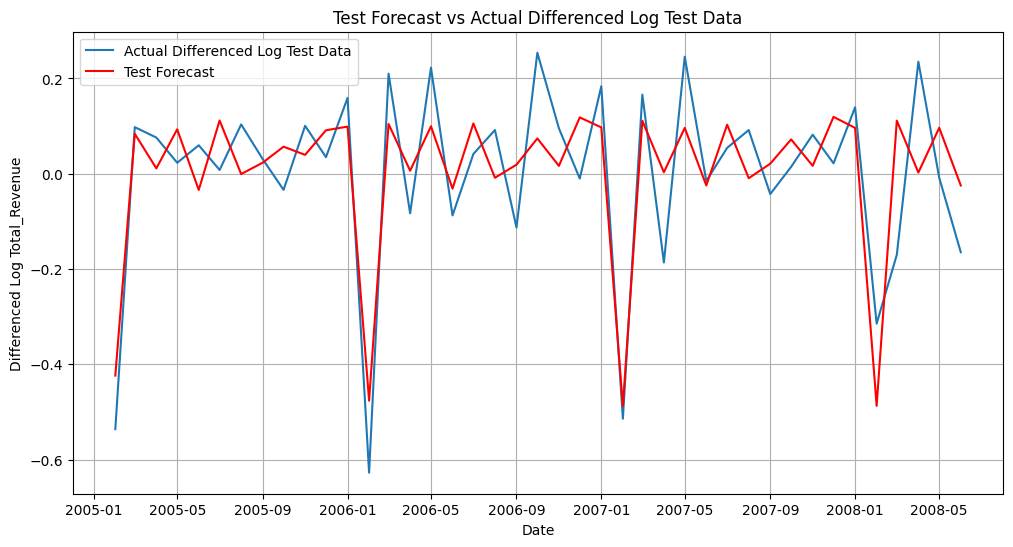

Test Forecast Evaluation:
  MAE: 0.0969
  MSE: 0.0126
  MAPE: 1.9256


In [ ]:
# Forecast pada data test
test_forecast = arima_model.predict(n_periods=len(test_data))

# Membuat pandas Series untuk test forecast
test_forecast_series = pd.Series(test_forecast, index=test_data.index)

# Plot the actual test data dan test forecast
plt.figure(figsize=(12, 6))
plt.plot(test_data, label='Actual Differenced Log Test Data')
plt.plot(test_forecast_series, color='red', label='Test Forecast')
plt.title('Test Forecast vs Actual Differenced Log Test Data')
plt.xlabel('Date')
plt.ylabel('Differenced Log Total_Revenue')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the test forecast using metrics
# Menjumlahkan Mean Absolute Error (MAE)
mae_test = mean_absolute_error(test_data, test_forecast_series)

# Menjumlahkan Mean Squared Error (MSE)
mse_test = mean_squared_error(test_data, test_forecast_series)

# Menjumlahkan Mean Absolute Percentage Error (MAPE)
# Tambahkan nilai epsilon kecil untuk menghindari pembagian oleh nol jika nilai aktualnya nol.
epsilon = 1e-10
mape_test = mean_absolute_percentage_error(test_data, test_forecast_series)


print(f'Test Forecast Evaluation:')
print(f'  MAE: {mae_test:.4f}')
print(f'  MSE: {mse_test:.4f}')
print(f'  MAPE: {mape_test:.4f}')

Grafik:

- Mengikuti Tren Umum: Garis merah (Test Forecast) berusaha mengikuti garis biru (Data Uji Logaritmik yang Diperbedaankan), menangkap pergerakan naik dan turun secara umum.
- Keterlambatan dalam Menangkap Perubahan Tajam: Ada kasus di mana data aktual menunjukkan puncak atau penurunan tajam yang tidak segera ditangkap oleh perkiraan dengan magnitudo atau waktu yang sama. Namun umum terjadi dalam Forecast data yang belum pernah dilihat sebelumnya, karena model belum pernah melihat fluktuasi spesifik ini sebelumnya.
- Pengenalan Pola Musiman: Grafik masih menunjukkan bahwa model menangkap pola musiman hingga batas tertentu, dengan peramalan umumnya mencapai puncak dan penurunan pada waktu yang sama dengan data aktual, walaupun amplitudonya mungkin tidak selalu cocok sempurna.

Metrik:

- MAE (Mean Absolute Error): 0.0969
Sama seperti full forecast, selisih absolut rata-rata antara test forecast dan data uji aktual sekitar 0.0969.
- MSE (Mean Squared Error): 0.0126
Kesalahan kuadrat rata-rata pada set uji adalah 0.0126.
- MAPE (Mean Absolute Percentage Error): 1.9256
Rata-rata kesalahan persentase pada set uji sekitar 1,93%.

terlihat bahwa nilai evaluasi matrik pada data test sama dengan full forecasting menunjukkan bahwa kinerja model pada data yang belum dilihat sebanding dengan kinerjanya pada data yang digunakan untuk pelatihan.

### Evaluate on Train Data

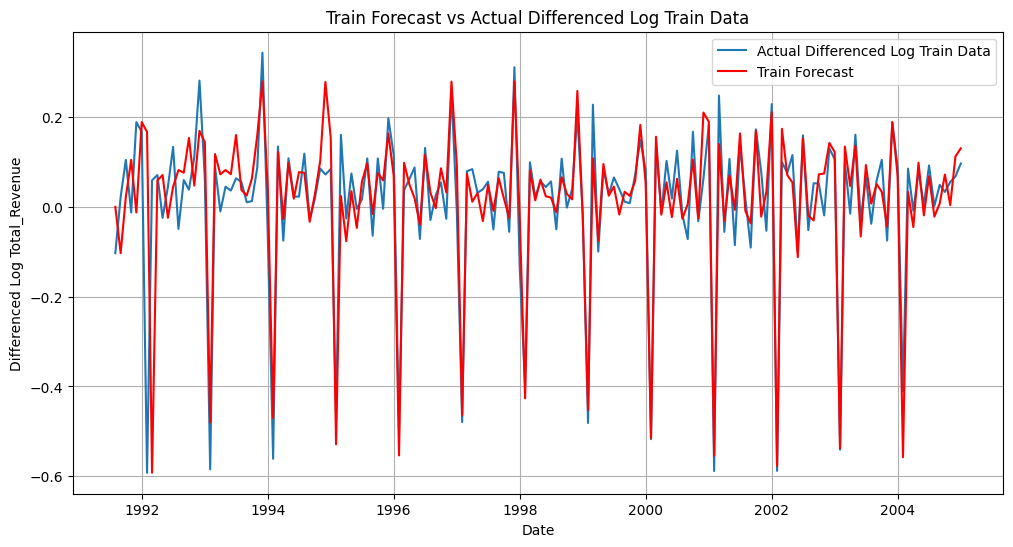

Train Forecast Evaluation:
  MAE: 0.0544
  MSE: 0.0098
  MAPE: 1.3663


In [ ]:
# Membuat predictions pada training data using predict_in_sample
train_forecast = arima_model.predict_in_sample()

# Membuat pandas Series untuk train forecast dengan index yang benar
# predict_in_sample returns an array, so we need to assign the index from train_data
train_forecast_series = pd.Series(train_forecast, index=train_data.index)


# Plot the actual train data and the train forecast
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Actual Differenced Log Train Data')
plt.plot(train_forecast_series, color='red', label='Train Forecast')
plt.title('Train Forecast vs Actual Differenced Log Train Data')
plt.xlabel('Date')
plt.ylabel('Differenced Log Total_Revenue')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the train forecast using metrics
# Menghitung Mean Absolute Error (MAE)
mae_train = mean_absolute_error(train_data, train_forecast_series)

# Menghitung Mean Squared Error (MSE)
mse_train = mean_squared_error(train_data, train_forecast_series)

# Menghitung Mean Absolute Percentage Error (MAPE)
# Add a small epsilon to avoid division by zero if value is zero
epsilon = 1e-10
mape_train = mean_absolute_percentage_error(train_data, train_forecast_series)


print(f'Train Forecast Evaluation:')
print(f'  MAE: {mae_train:.4f}')
print(f'  MSE: {mse_train:.4f}')
print(f'  MAPE: {mape_train:.4f}')

Grafik:

 Red line (Train Forecast) mengikuti blue line (Actual Differenced Log Train Data) dengan sangat dekat. Merupakan hal yang diharapkan karena model dilatih menggunakan data train, Perkiraan tersebut secara akurat menangkap fluktuasi dan pola dalam periode pelatihan.

Matrik:

- MAE (Mean Absolute Error): 0.0544  
Rata-rata selisih absolut antara Train Forecas dan data train aktual adalah sekitar 0.0544. Nilai MAE lebih rendah daripada MAE pada data uji (0.0969), yang merupakan hal yang baik karena mengharapkan model berperforma lebih baik pada data yang telah dilihatnya.
- MSE (Mean Squared Error): 0.0098
Rata-rata kesalahan kuadrat pada set train adalah 0.0098. Serupa dengan MAE, ini lebih rendah daripada MSE pada data test (0.0126), menunjukkan kesesuaian yang lebih baik pada data train.
- MAPE (Mean Absolute Percentage Error): 1.3663
Rata-rata kesalahan persentase pada set train adalah sekitar 1,37%. Nilai ini lebih rendah daripada MAPE pada data test (1,9256%), mengonfirmasi kesesuaian yang lebih baik pada data train.

### Future Prediction

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-140.820, Time=0.35 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-280.798, Time=1.75 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,1,2)(5,1,0)[12]             : AIC=inf, Time=41.60 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(5,1,1)(5,1,0)[12] intercept   : AIC=-486.538, Time=45.53 sec

Best model:  ARIMA(5,1,1)(5,1,0)[12]          
Total fit time: 601.611 seconds
Future Predictions (Original Scale):
2008-07-01    25.230773
2008-08-01    24.238370
2008-09-01    24.662859
2008-10-01    26.969172
2008-11-01    25.945422
2008-12-01    28.405294
2009-01-01    33.118643
2009-02-01    20.133827
2009-03-01    21.020821
2009-04-01    22.829874
2009-05-01    24.477116
2009-06-01    22.731961
2009-07-01    25.955633
2009-08-01    25.791791
2009-09-01    26.020833
2009-10-01    29.452373
2009-11-01    29.503015
2009-12-01    32.156968
2010-01-01    36.850533
2010-02-01    22.199139
2010-03-01    24.937736
2010-04-01    24.202640
2010-05-01    27.407706
2010-06-01    27.003273
Freq: MS, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


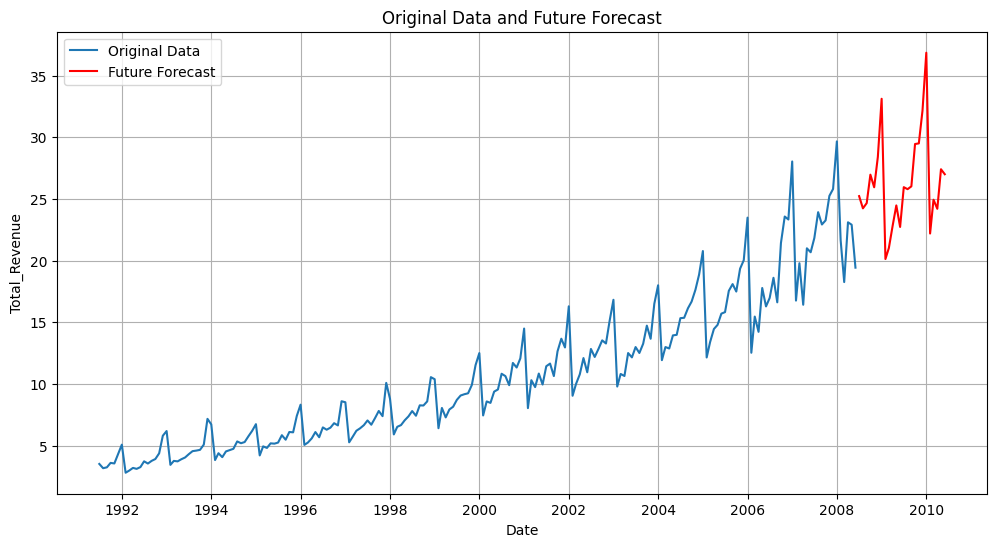

In [ ]:
# Specify the number of periods to forecast into the future
n_periods_future = 24 # For example, forecast for the next 24 months

# Train the Auto ARIMA model on the entire differenced log-transformed dataset
full_arima_model = auto_arima(ts_log_diff, start_p=0, d=1, start_q=0,
                         max_p=5, max_d=5, max_q=5, start_P=0,
                         D=1, start_Q=0, max_P=5, max_D=5,
                         max_Q=5, m=12, seasonal=True,
                         error_action='warn', trace=True,
                         suppress_warnings=True, stepwise=True,
                         random_state=20, n_fits=50)


# Generate future predictions using the trained model on the full dataset
# Since the model was trained on differenced log data, the forecast will be in that scale
future_forecast_diff_log = full_arima_model.predict(n_periods=n_periods_future)

# Create a pandas Series for the future forecast with appropriate future dates as index
# We need to create future dates starting from the end of the original time series
last_date = ts.index[-1]
future_dates = pd.date_range(start=last_date, periods=n_periods_future + 1, freq='MS')[1:] # Start from the next month

future_forecast_diff_log_series = pd.Series(future_forecast_diff_log, index=future_dates)

# Inverse the differencing
# To inverse the differencing, we need to add the last value of the original log-transformed series
# to the cumulative sum of the differenced log forecast.
last_log_value = ts_log.iloc[-1]
future_forecast_log = last_log_value + future_forecast_diff_log_series.cumsum()

# Inverse the log transformation
# Apply the exponential function to get the forecast in the original scale
future_forecast_original_scale = numpy.exp(future_forecast_log)

# Display the future predictions
print("Future Predictions (Original Scale):")
print(future_forecast_original_scale)

# Plot the original data and the future forecast
plt.figure(figsize=(12, 6))
plt.plot(ts, label='Original Data')
plt.plot(future_forecast_original_scale, color='red', label='Future Forecast')
plt.title('Original Data and Future Forecast')
plt.xlabel('Date')
plt.ylabel('Total_Revenue')
plt.legend()
plt.grid(True)
plt.show()

Insights Future Predictions:

- Trend Naik Berlanjut (Continuing Upward Trend): Nilai-nilai yang diprediksi secara umum menunjukkan kelanjutan dari tren naik yang diamati dalam data historis. ‘Total_Revenue’ diperkirakan akan meningkat selama 24 bulan ke depan.
- Pola Musiman yang Terjaga (Preserved Seasonality): Prediksi menunjukkan pola musiman yang jelas, konsisten dengan pola musiman tahunan yang diidentifikasi sebelumnya dalam data. Terdapat puncak dan lembah yang berulang pada waktu yang serupa setiap tahun dalam periode perkiraan. Misalnya, nilai-nilai cenderung lebih tinggi pada akhir tahun dan lebih rendah pada awal tahun.
- Amplitudo Musiman yang Meningkat (Increasing Amplitude of Seasonality): Sama dengan data historis, amplitudo fluktuasi musiman terlihat meningkat seiring waktu dalam perkiraan untuk masa depan.

Grafik Insight:
- Perpanjangan Pola Historis (Extension of Historical Pattern): red line yang mewakili “Perkiraan Masa Depan” secara mulus berlanjut dari akhir blue line yang mewakili “Data Asli”. Secara visual, tren dan pola musiman yang diamati berlanjut ke masa depan.
- Puncak dan Lembah Musiman (Seasonal Peaks and Troughs) : Grafik dengan jelas menunjukkan puncak dan lembah musiman yang forecast, memperkuat penemuan bahwa musiman tetap terjaga dan meningkat.

Umum:

Future predictions yang dihasilkan oleh model Auto ARIMA, setelah melakukan transformasi invers pada  differenced log values, memberikan forecast yang wajar untuk ‘Total_Revenue’ dalam skala aslinya. forecast  mempertahankan karakteristik utama data historis, termasuk tren naik dan musiman tahunan yang bersifat multiplikatif.


### Save Future Predictions to Excel

In [ ]:
# Membuat DataFrame dari future predictions
# Series index (dates) akan menjadi kolom
future_predictions_df = future_forecast_original_scale.reset_index()

# Memberi nama columns untuk clarity
future_predictions_df.columns = ['Date', 'Predicted_Total_Revenue']

# Tampilkan beberapa baris pertama dari DataFrame
display(future_predictions_df.head())

# Nama file untuk file Excel.
excel_filename = 'future_predictions.xlsx'

# Save the DataFrame to an Excel file
# Set index=False to avoid writing the DataFrame index as a column in the Excel file
future_predictions_df.to_excel(excel_filename, index=False)

print(f"\nFuture predictions saved to '{excel_filename}'")

,Date,Predicted_Total_Revenue
0,2008-07-01,25.230773
1,2008-08-01,24.238370
2,2008-09-01,24.662859
3,2008-10-01,26.969172
4,2008-11-01,25.945422



Future predictions saved to 'future_predictions.xlsx'


### Save the Trained Model

In [ ]:
# Membuat nama file untuk model yang disimpan.
model_filename = 'full_arima_model.pkl'

# Simpan model yang telah dilatih menggunakan joblib
joblib.dump(full_arima_model, model_filename)

print(f"Trained model saved to '{model_filename}'")

Trained model saved to 'full_arima_model.pkl'
